# 🔥 Indoor Fire Dataset — Exploratory Data Analysis

**Source:** [Mendeley Data — npk2zcm85h](https://data.mendeley.com/datasets/npk2zcm85h/1)  
**Paper:** Pascal V, Otto von Guericke Universität Magdeburg, 2023  
**Size:** 305,304 rows · 9 sensor nodes · EN54 test room  
**Labels:** `ternary_label` → Fire / Nuisance / Background  
**Scenarios:** Cable, Candles, Lunts, Wood · Ethanol, Deodorant, Hairspray  

## 0. Install & Import

In [3]:
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
ROOT_DIR = Path.cwd().parent.parent
DATA_PATH = ROOT_DIR / 'data' / 'Indoor Fire Dataset with Distributed Multi-Sensor Nodes.csv'

plt.rcParams['figure.facecolor'] = '#F8F9FA'
plt.rcParams['axes.facecolor']   = '#FAFAFA'
plt.rcParams['font.size']        = 10

# ── Colour palettes ──
SCENARIO_COLORS = {
    'Background': '#95A5A6', 'Cable':    '#8E44AD',
    'Candles':    '#F39C12', 'Deodorant':'#3498DB',
    'Ethanol':    '#1ABC9C', 'Hairspray':'#E91E8C',
    'Lunts':      '#E74C3C', 'Wood':     '#784212',
}
TERNARY_COLORS = {
    'Background': '#95A5A6',
    'Fire':       '#E74C3C',
    'Nuisance':   '#F39C12',
}

## 1. Load Data

In [5]:
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'], format='ISO8601', utc=True)

print(f'Shape : {df.shape}')
print(f'Period: {df["Date"].min()} → {df["Date"].max()}')
print(f'Sensor nodes: {df["Sensor_ID"].nunique()}')
display(df.head(3))
display(df.dtypes.to_frame('dtype'))

Shape : (305304, 19)
Period: 2022-07-04 14:10:54.259355+00:00 → 2022-07-08 12:29:11.246358+00:00
Sensor nodes: 9


,Date,Sensor_ID,CO2_Room,CO_Room,H2_Room,Humidity_Room,PM05_Room,PM100_Room,PM10_Room,PM25_Room,PM40_Room,PM_Room_Typical_Size,PM_Total_Room,Temperature_Room,UV_Room,VOC_Room_RAW,scenario_label,anomaly_label,ternary_label
0,2022-07-04 14:10:54.259355+00:00,Sensorknoten0009,1150.0,-0.43,0.13,51.50,15.0,0.0,2.0,0.0,0.0,0.40,17.0,26.3,0.0,0.5,Background,Normal,Background
1,2022-07-04 14:10:54.401380+00:00,Sensorknoten0015,1300.0,-0.08,0.12,52.85,7.0,0.0,0.0,0.0,0.0,0.45,8.0,25.7,0.0,0.5,Background,Normal,Background
2,2022-07-04 14:10:55.401182+00:00,Sensorknoten0011,412.0,-0.08,0.22,50.60,16.0,0.0,2.0,0.0,0.0,0.47,19.0,26.5,0.0,0.5,Background,Normal,Background


,dtype
Date,"datetime64[ns, UTC]"
Sensor_ID,object
CO2_Room,float64
CO_Room,float64
H2_Room,float64
Humidity_Room,float64
PM05_Room,float64
PM100_Room,float64
PM10_Room,float64
PM25_Room,float64


## 2. Basic Inspection

In [6]:
# Missing values
print('Missing values:')
display(df.isnull().sum().to_frame('missing').T)

# Label distributions
print('\nternary_label:')
display(df['ternary_label'].value_counts(normalize=True).mul(100).round(2).to_frame('%'))

print('\nscenario_label:')
display(df['scenario_label'].value_counts().to_frame('count'))

print(f'\nSensor IDs ({df["Sensor_ID"].nunique()}):')
print(df['Sensor_ID'].unique())

Missing values:


,Date,Sensor_ID,CO2_Room,CO_Room,H2_Room,Humidity_Room,PM05_Room,PM100_Room,PM10_Room,PM25_Room,PM40_Room,PM_Room_Typical_Size,PM_Total_Room,Temperature_Room,UV_Room,VOC_Room_RAW,scenario_label,anomaly_label,ternary_label
missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



ternary_label:


,%
ternary_label,
Background,82.98
Fire,12.50
Nuisance,4.53



scenario_label:


,count
scenario_label,
Background,253327
Cable,10658
Lunts,9605
Wood,9213
Ethanol,9076
Candles,8672
Deodorant,3170
Hairspray,1583



Sensor IDs (9):
['Sensorknoten0009' 'Sensorknoten0015' 'Sensorknoten0011'
 'Sensorknoten0012' 'Sensorknoten0016' 'Sensorknoten0014'
 'Sensorknoten0013' 'Sensorknoten0008' 'Sensorknoten0010']


## 3. Define Feature Sets — Drop Redundant PM Columns

In [7]:
ALL_SENSORS = [
    'CO2_Room', 'CO_Room', 'H2_Room', 'Humidity_Room',
    'PM05_Room', 'PM100_Room', 'PM10_Room', 'PM25_Room', 'PM40_Room',
    'PM_Room_Typical_Size', 'PM_Total_Room',
    'Temperature_Room', 'UV_Room', 'VOC_Room_RAW',
]

# PM25 ≈ PM40 (corr=1.00), PM100 ≈ PM10 (corr=0.98) → drop 3 redundant cols
DROP_COLS  = ['PM25_Room', 'PM40_Room', 'PM100_Room']
KEEP_SENSORS = [c for c in ALL_SENSORS if c not in DROP_COLS]

print(f'Dropped (redundant PM): {DROP_COLS}')
print(f'Kept ({len(KEEP_SENSORS)} features): {KEEP_SENSORS}')

# Helper binary columns
df['anomaly_bin']  = (df['anomaly_label'] == 'Anomaly').astype(int)
df['fire_bin']     = (df['ternary_label'] == 'Fire').astype(int)
df['nuisance_bin'] = (df['ternary_label'] == 'Nuisance').astype(int)

Dropped (redundant PM): ['PM25_Room', 'PM40_Room', 'PM100_Room']
Kept (11 features): ['CO2_Room', 'CO_Room', 'H2_Room', 'Humidity_Room', 'PM05_Room', 'PM10_Room', 'PM_Room_Typical_Size', 'PM_Total_Room', 'Temperature_Room', 'UV_Room', 'VOC_Room_RAW']


## 4. Descriptive Statistics

In [8]:
display(df[KEEP_SENSORS].describe().round(3))

,CO2_Room,CO_Room,H2_Room,Humidity_Room,PM05_Room,PM10_Room,PM_Room_Typical_Size,PM_Total_Room,Temperature_Room,UV_Room,VOC_Room_RAW
count,305304.000,305304.000,305304.000,305304.000,305304.000,305304.000,305304.000,305304.000,305304.000,305304.000,305304.000
mean,688.691,0.286,0.231,44.000,994.458,193.876,0.437,1226.666,25.358,1.978,1.888
std,158.518,0.907,0.647,3.202,4303.129,984.409,0.081,5451.818,0.518,21.378,2.712
min,97.000,-1.300,-2.250,35.080,0.000,0.000,0.340,0.000,23.700,0.000,-1.600
25%,611.000,-0.140,0.020,42.040,4.000,0.000,0.400,5.000,25.000,0.000,0.800
50%,695.000,0.130,0.120,43.600,7.000,1.000,0.420,9.000,25.300,0.000,1.400
75%,759.000,0.420,0.230,45.130,14.000,2.000,0.440,16.000,25.800,0.000,1.900
max,1651.000,32.220,16.360,55.970,44471.000,48301.000,1.570,93048.000,28.100,406.000,75.300


In [9]:
# Mean per scenario
display(
    df.groupby('scenario_label')[KEEP_SENSORS]
    .mean().round(3).T
    .style.background_gradient(cmap='YlOrRd', axis=1)
)

scenario_label,Background,Cable,Candles,Deodorant,Ethanol,Hairspray,Lunts,Wood
CO2_Room,681.813000,672.289000,795.702000,653.260000,638.256000,637.623000,714.994000,839.292000
CO_Room,0.074000,0.505000,0.197000,1.999000,1.756000,2.596000,1.964000,1.757000
H2_Room,0.104000,0.829000,0.240000,0.106000,-0.066000,0.077000,2.222000,1.300000
Humidity_Room,44.412000,41.832000,42.795000,41.619000,39.913000,41.934000,41.687000,43.918000
PM05_Room,8.424000,6499.896000,6490.821000,24.746000,4.038000,29.747000,6843.786000,11941.505000
PM10_Room,0.739000,1736.293000,968.367000,6.468000,0.128000,7.364000,1045.958000,2390.207000
PM_Room_Typical_Size,0.414000,0.663000,0.477000,0.623000,0.410000,0.687000,0.522000,0.606000
PM_Total_Room,9.714000,8781.529000,7515.616000,33.990000,4.690000,39.996000,7965.710000,14821.677000
Temperature_Room,25.316000,25.405000,25.861000,25.082000,25.342000,25.098000,25.574000,25.912000
UV_Room,0.065000,0.141000,67.379000,0.025000,0.026000,0.019000,0.022000,0.120000


## 5. Label Distribution Plots

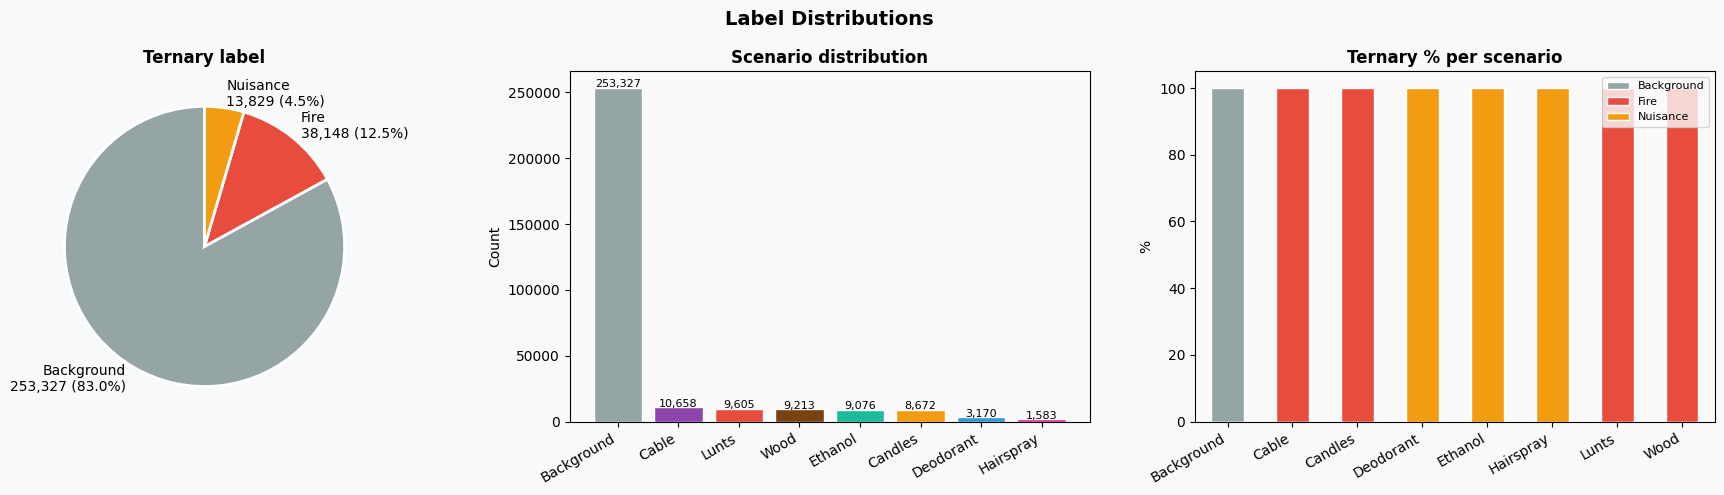

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Label Distributions', fontsize=14, fontweight='bold')

# 5a. Ternary pie
ax = axes[0]
tc = df['ternary_label'].value_counts()
ax.pie(
    tc.values,
    labels=[f'{l}\n{v:,} ({v/len(df)*100:.1f}%)' for l, v in zip(tc.index, tc.values)],
    colors=[TERNARY_COLORS[l] for l in tc.index],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
ax.set_title('Ternary label', fontweight='bold')

# 5b. Scenario bar
ax = axes[1]
sc = df['scenario_label'].value_counts()
bars = ax.bar(sc.index, sc.values,
              color=[SCENARIO_COLORS[l] for l in sc.index],
              edgecolor='white')
ax.set_title('Scenario distribution', fontweight='bold')
ax.set_xticklabels(sc.index, rotation=30, ha='right')
ax.set_ylabel('Count')
for bar, val in zip(bars, sc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', fontsize=8)

# 5c. Scenario → ternary stacked
ax = axes[2]
ct = pd.crosstab(df['scenario_label'], df['ternary_label'], normalize='index') * 100
ct[['Background','Fire','Nuisance']].plot(
    kind='bar', stacked=True, ax=ax,
    color=[TERNARY_COLORS['Background'], TERNARY_COLORS['Fire'], TERNARY_COLORS['Nuisance']],
    edgecolor='white',
)
ax.set_title('Ternary % per scenario', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('%')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Correlation Analysis

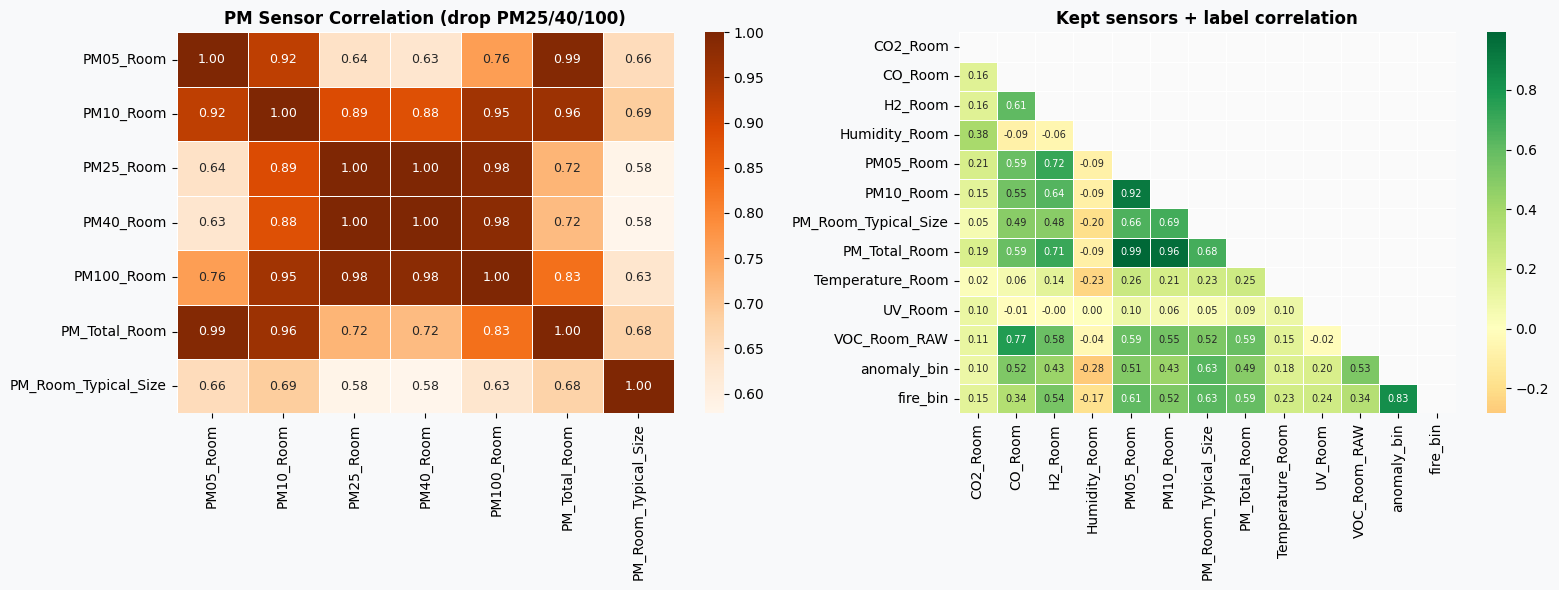

In [11]:
# 6a. Redundant PM check
pm_cols = ['PM05_Room','PM10_Room','PM25_Room','PM40_Room','PM100_Room',
           'PM_Total_Room','PM_Room_Typical_Size']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    df[pm_cols].corr(), annot=True, fmt='.2f', cmap='Oranges',
    ax=axes[0], linewidths=0.5, annot_kws={'size': 9},
)
axes[0].set_title('PM Sensor Correlation (drop PM25/40/100)', fontweight='bold')

# 6b. Full kept-sensor heatmap
corr = df[KEEP_SENSORS + ['anomaly_bin', 'fire_bin']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    ax=axes[1], mask=mask, linewidths=0.5, annot_kws={'size': 7},
)
axes[1].set_title('Kept sensors + label correlation', fontweight='bold')
plt.tight_layout()
plt.show()

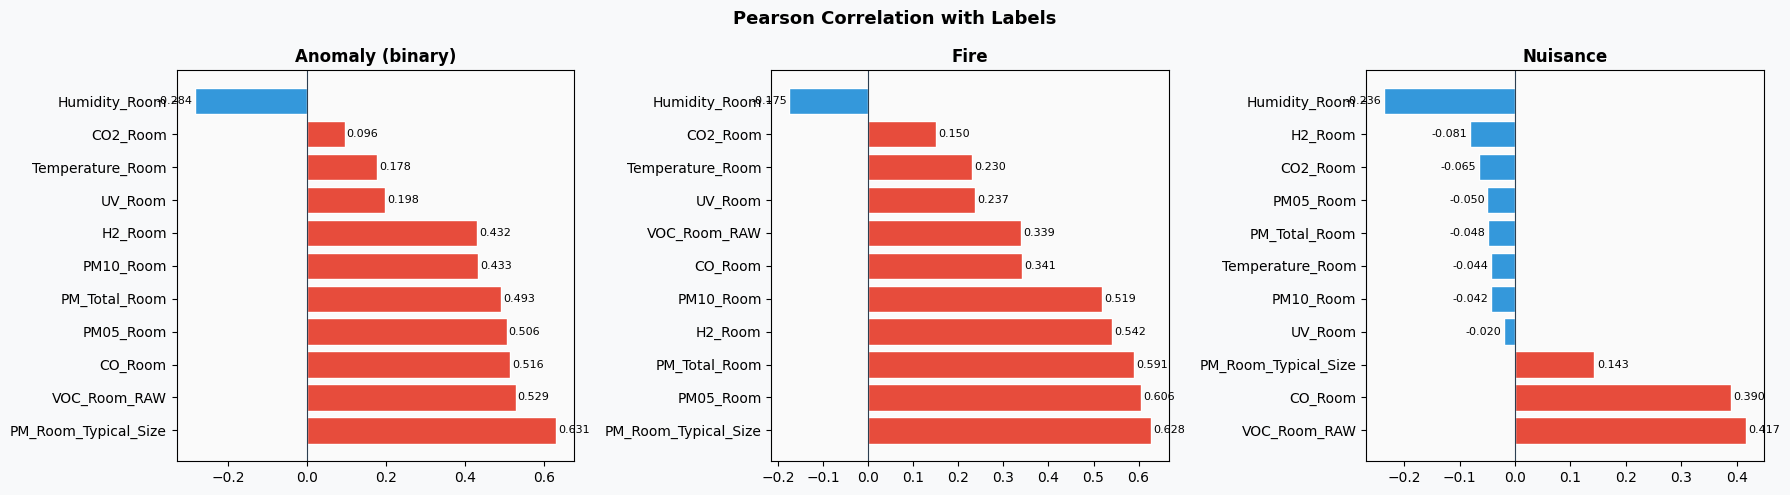

In [12]:
# Correlation with each label — sorted
corr_anom = df[KEEP_SENSORS].corrwith(df['anomaly_bin']).sort_values(ascending=False)
corr_fire = df[KEEP_SENSORS].corrwith(df['fire_bin']).sort_values(ascending=False)
corr_nuis = df[KEEP_SENSORS].corrwith(df['nuisance_bin']).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Pearson Correlation with Labels', fontsize=13, fontweight='bold')

for ax, corr_s, title in zip(
    axes,
    [corr_anom, corr_fire, corr_nuis],
    ['Anomaly (binary)', 'Fire', 'Nuisance'],
):
    colors = ['#E74C3C' if v > 0 else '#3498DB' for v in corr_s.values]
    ax.barh(corr_s.index, corr_s.values, color=colors, edgecolor='white')
    ax.axvline(0, color='#2C3E50', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    for i, (idx, val) in enumerate(corr_s.items()):
        ax.text(val + (0.005 if val >= 0 else -0.005), i,
                f'{val:.3f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

## 7. KDE Distributions per Ternary Label

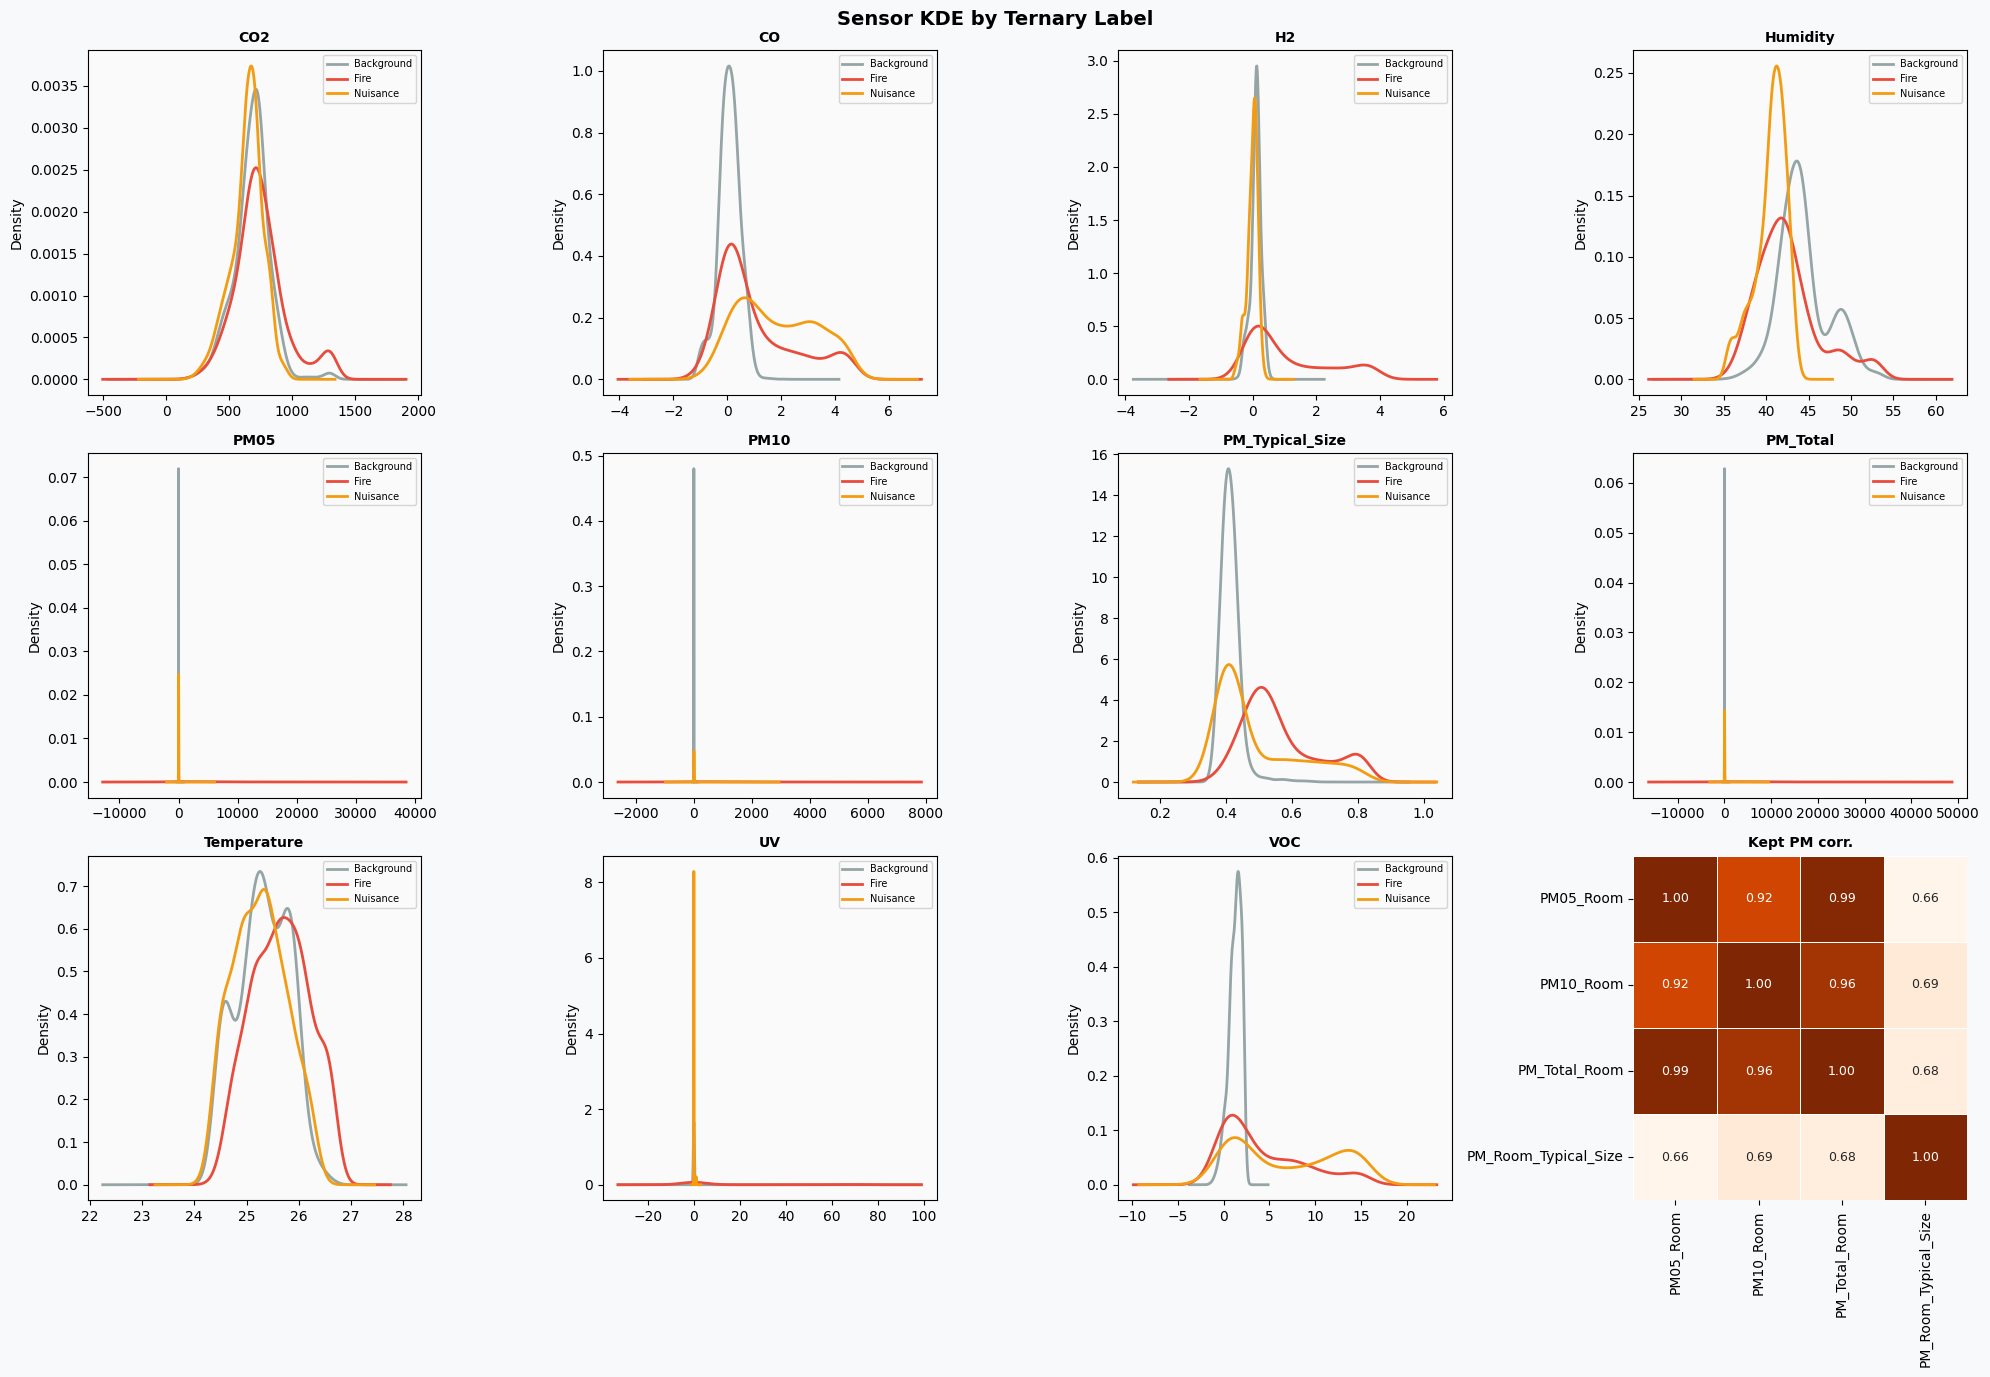

In [13]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
fig.suptitle('Sensor KDE by Ternary Label', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, sensor in enumerate(KEEP_SENSORS):
    ax = axes[i]
    q99 = df[sensor].quantile(0.99)     # clip for readability
    for label, color in TERNARY_COLORS.items():
        data = df[df['ternary_label'] == label][sensor].clip(upper=q99)
        try:
            data.plot.kde(ax=ax, color=color, linewidth=2,
                          label=label, bw_method=0.3)
        except Exception:
            ax.hist(data, bins=30, alpha=0.4, color=color, label=label)
    ax.set_title(sensor.replace('_Room', '').replace('_RAW', ''),
                 fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    ax.set_xlabel('')

# Extra: PM correlation mini-heatmap
ax = axes[-1]
pm_mini = df[['PM05_Room','PM10_Room','PM_Total_Room','PM_Room_Typical_Size']].corr()
sns.heatmap(pm_mini, annot=True, fmt='.2f', cmap='Oranges', ax=ax,
            linewidths=0.5, annot_kws={'size': 9}, cbar=False)
ax.set_title('Kept PM corr.', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Boxplots per Scenario (log scale for PM/VOC)

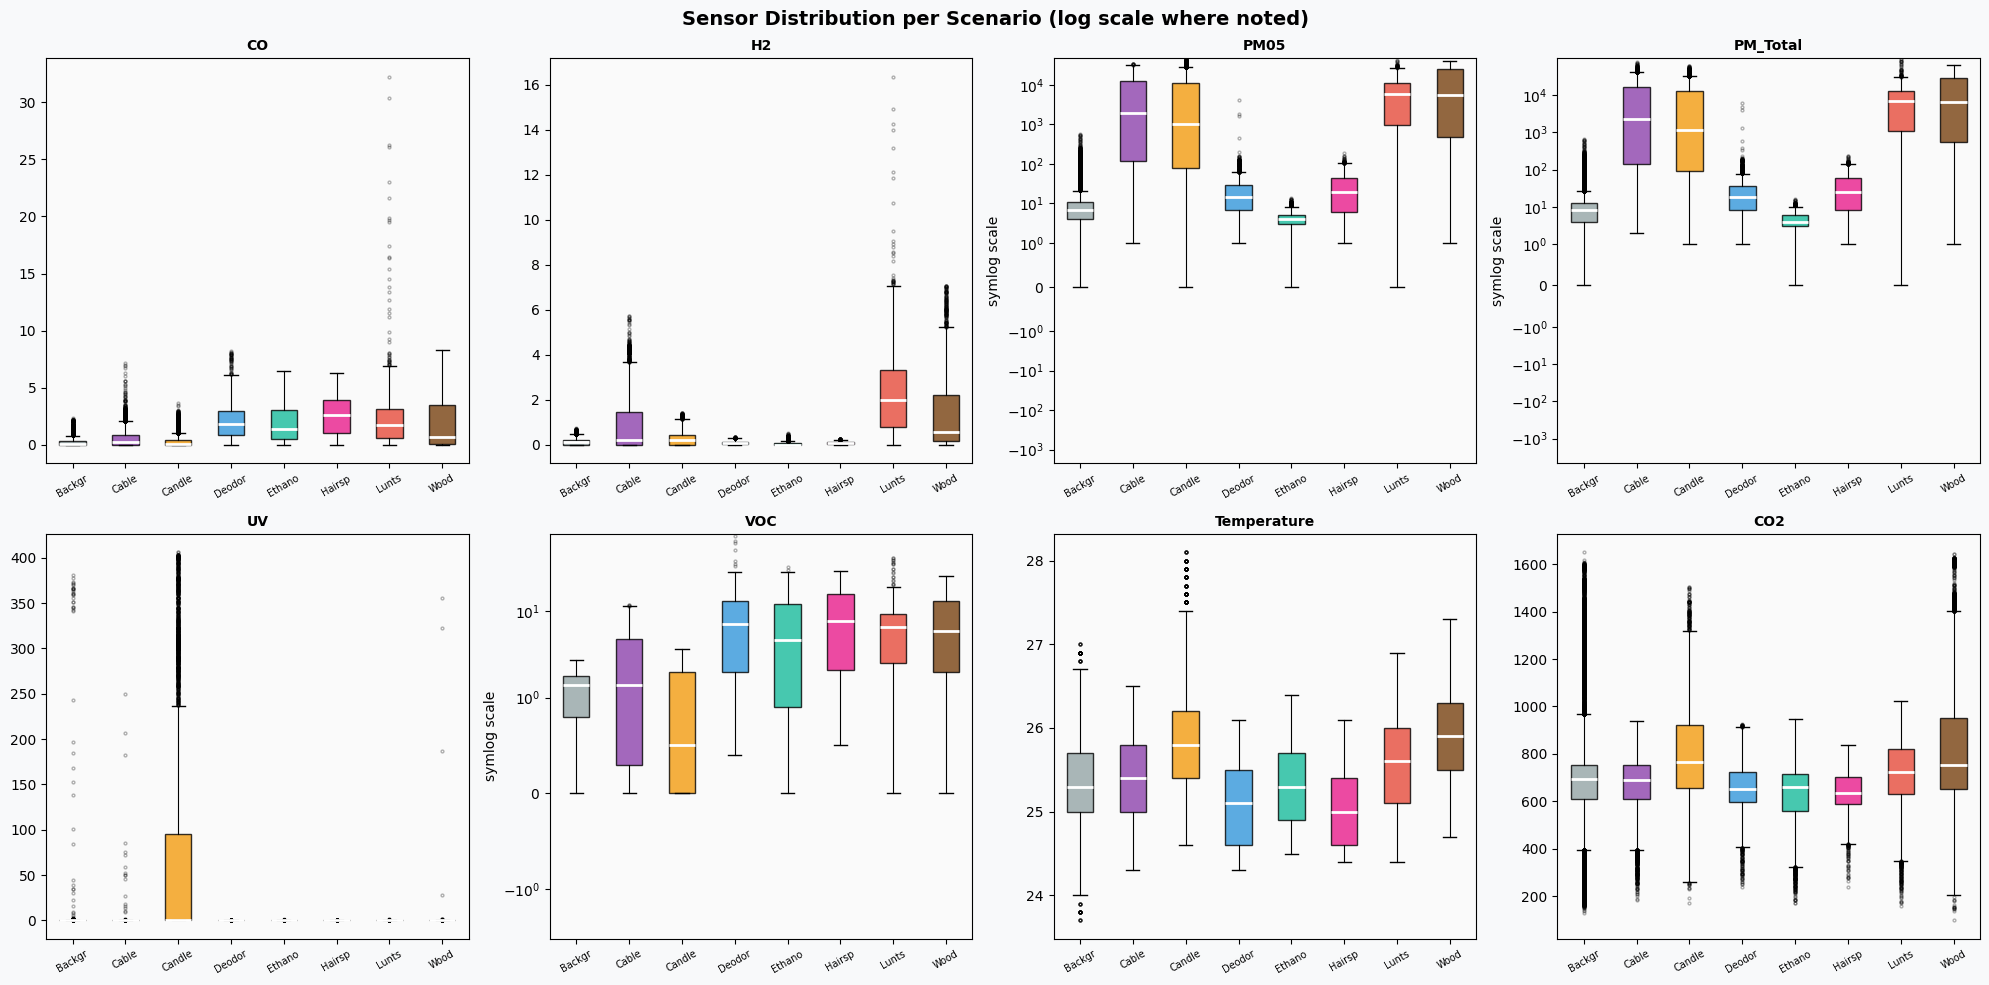

In [14]:
TOP8 = ['CO_Room','H2_Room','PM05_Room','PM_Total_Room',
        'UV_Room','VOC_Room_RAW','Temperature_Room','CO2_Room']

scenarios = list(SCENARIO_COLORS.keys())
sc_palette = [SCENARIO_COLORS[s] for s in scenarios]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Sensor Distribution per Scenario (log scale where noted)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, sensor in enumerate(TOP8):
    ax = axes[i]
    data_list = [
        df[df['scenario_label'] == sc][sensor].clip(lower=0).dropna()
        for sc in scenarios
    ]
    bp = ax.boxplot(
        data_list, patch_artist=True,
        medianprops={'color': 'white', 'linewidth': 2},
        whiskerprops={'linewidth': 0.8},
        flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3},
    )
    for patch, color in zip(bp['boxes'], sc_palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticks(range(1, len(scenarios) + 1))
    ax.set_xticklabels([s[:6] for s in scenarios], fontsize=7, rotation=30)
    ax.set_title(sensor.replace('_Room','').replace('_RAW',''),
                 fontweight='bold', fontsize=10)
    if sensor in ['PM05_Room','PM_Total_Room','VOC_Room_RAW']:
        ax.set_yscale('symlog', linthresh=1)
        ax.set_ylabel('symlog scale')

plt.tight_layout()
plt.show()

## 9. UV Special Analysis (Candles only)

In [15]:
print('UV_Room non-zero % per scenario:')
for sc in df['scenario_label'].unique():
    d = df[df['scenario_label'] == sc]['UV_Room']
    nonzero = (d > 0.5).mean() * 100
    print(f'  {sc:<15}: {nonzero:5.1f}%  (mean={d.mean():.2f})')

print('\nTemperature delta vs background:')
bg_temp = df[df['ternary_label'] == 'Background']['Temperature_Room'].mean()
for sc in df['scenario_label'].unique():
    if sc == 'Background':
        continue
    t = df[df['scenario_label'] == sc]['Temperature_Room'].mean()
    print(f'  {sc:<15}: mean={t:.2f}°C  Δ={t-bg_temp:+.2f}°C')

UV_Room non-zero % per scenario:
  Background     :   2.5%  (mean=0.07)
  Wood           :   2.3%  (mean=0.12)
  Candles        :  47.9%  (mean=67.38)
  Cable          :   2.8%  (mean=0.14)
  Ethanol        :   2.6%  (mean=0.03)
  Lunts          :   2.2%  (mean=0.02)
  Deodorant      :   2.5%  (mean=0.03)
  Hairspray      :   1.9%  (mean=0.02)

Temperature delta vs background:
  Wood           : mean=25.91°C  Δ=+0.60°C
  Candles        : mean=25.86°C  Δ=+0.54°C
  Cable          : mean=25.41°C  Δ=+0.09°C
  Ethanol        : mean=25.34°C  Δ=+0.03°C
  Lunts          : mean=25.57°C  Δ=+0.26°C
  Deodorant      : mean=25.08°C  Δ=-0.23°C
  Hairspray      : mean=25.10°C  Δ=-0.22°C


## 10. Time Series — Single Node

Node Sensorknoten0009: 33914 rows


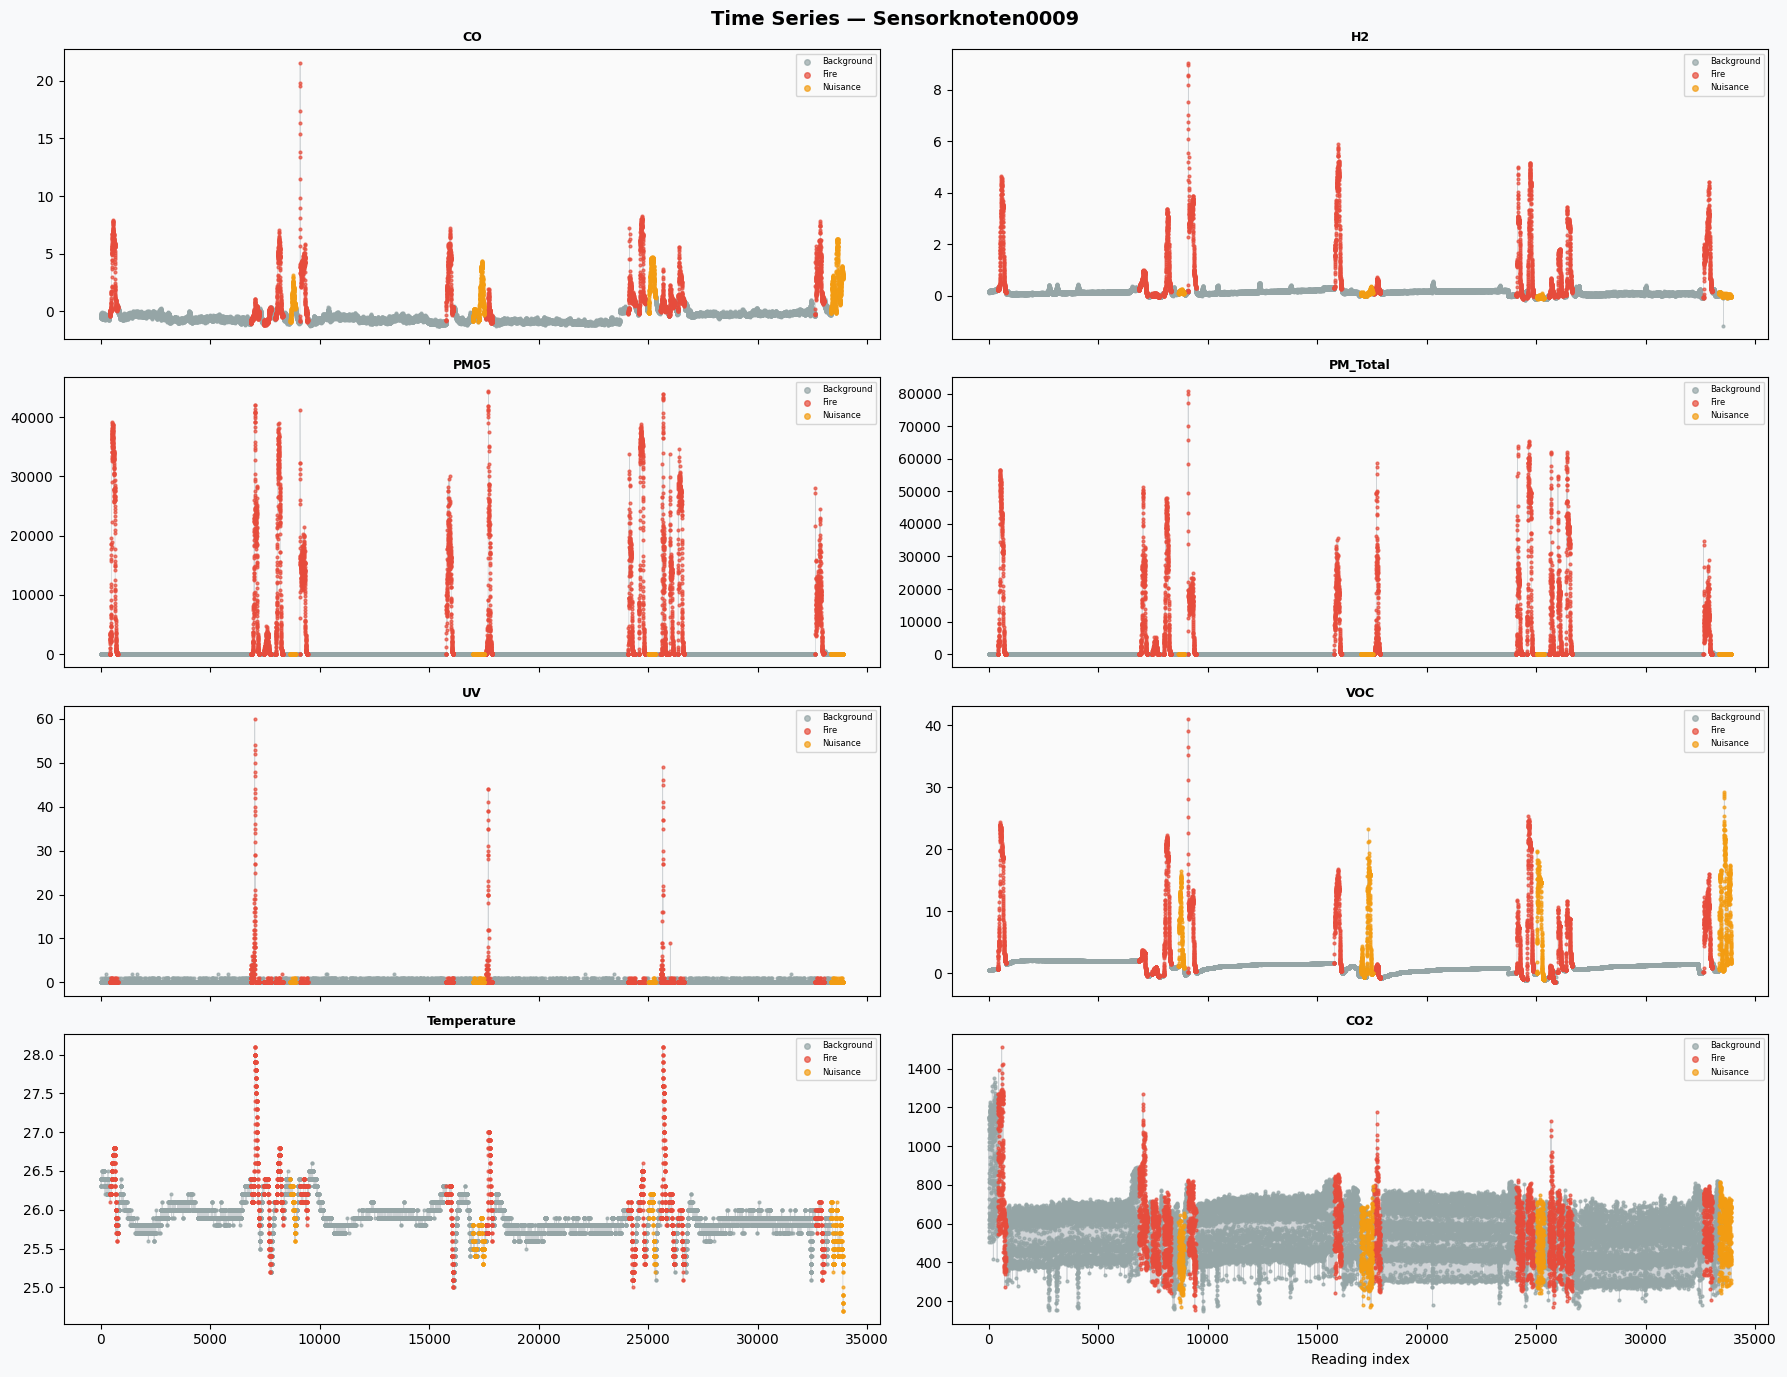

In [16]:
NODE = 'Sensorknoten0009'   # ← change to any node
node_df = df[df['Sensor_ID'] == NODE].reset_index(drop=True)
print(f'Node {NODE}: {len(node_df)} rows')

fig, axes = plt.subplots(4, 2, figsize=(18, 14), sharex=True)
fig.suptitle(f'Time Series — {NODE}', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, sensor in enumerate(TOP8):
    ax = axes[i]
    ax.plot(node_df.index, node_df[sensor],
            color='#BDC3C7', linewidth=0.5, alpha=0.7)
    for label, color in TERNARY_COLORS.items():
        mask = node_df['ternary_label'] == label
        ax.scatter(node_df[mask].index, node_df[mask][sensor],
                   c=color, s=4, alpha=0.7, zorder=3, label=label)
    ax.set_title(sensor.replace('_Room','').replace('_RAW',''),
                 fontweight='bold', fontsize=9)
    ax.legend(fontsize=6, markerscale=2)

axes[-1].set_xlabel('Reading index')
plt.tight_layout()
plt.show()

## 11. Stationarity Test (ADF)

In [17]:
print(f'ADF Test on node {NODE}\n')
print(f'{"Sensor":<25} {"ADF stat":>10} {"p-value":>10} {"Stationary":>12}')
print('-' * 62)
for sensor in KEEP_SENSORS:
    series = node_df[sensor].dropna()
    try:
        adf_stat, p_val, *_ = adfuller(series, autolag='AIC')
        stat = '✓' if p_val < 0.05 else '✗ NON'
        print(f'{sensor:<25} {adf_stat:>10.3f} {p_val:>10.4f} {stat:>12}')
    except Exception as e:
        print(f'{sensor:<25} ERROR: {e}')

ADF Test on node Sensorknoten0009

Sensor                      ADF stat    p-value   Stationary
--------------------------------------------------------------
CO2_Room                      -8.791     0.0000            ✓
CO_Room                       -9.685     0.0000            ✓
H2_Room                      -11.871     0.0000            ✓
Humidity_Room                 -3.176     0.0214            ✓
PM05_Room                    -12.315     0.0000            ✓
PM10_Room                    -12.432     0.0000            ✓
PM_Room_Typical_Size          -8.060     0.0000            ✓
PM_Total_Room                -12.121     0.0000            ✓
Temperature_Room             -10.096     0.0000            ✓
UV_Room                      -18.409     0.0000            ✓
VOC_Room_RAW                 -12.808     0.0000            ✓


## 12. Outlier Detection (Z-score)

In [18]:
print('Outliers (|z| > 3) per sensor:')
outlier_rows = []
for sensor in KEEP_SENSORS:
    z   = np.abs(stats.zscore(df[sensor].dropna()))
    cnt = (z > 3).sum()
    pct = (z > 3).mean() * 100
    outlier_idx = df[sensor].dropna()[z > 3].index
    fire_pct = (df.loc[outlier_idx, 'fire_bin'] == 1).mean() * 100
    nuis_pct = (df.loc[outlier_idx, 'nuisance_bin'] == 1).mean() * 100
    outlier_rows.append({
        'Sensor': sensor, 'Outliers': cnt, '%': round(pct, 2),
        '% = Fire': round(fire_pct, 1), '% = Nuisance': round(nuis_pct, 1),
    })

display(
    pd.DataFrame(outlier_rows).set_index('Sensor')
    .style.background_gradient(cmap='YlOrRd', subset=['%', '% = Fire'])
)

Outliers (|z| > 3) per sensor:


,Outliers,%,% = Fire,% = Nuisance
Sensor,,,,
CO2_Room,5255,1.720000,44.400000,0.200000
CO_Room,9138,2.990000,58.900000,41.100000
H2_Room,8701,2.850000,100.000000,0.000000
Humidity_Room,1390,0.460000,16.700000,0.000000
PM05_Room,9142,2.990000,100.000000,0.000000
PM10_Room,6623,2.170000,100.000000,0.000000
PM_Room_Typical_Size,9648,3.160000,79.700000,19.500000
PM_Total_Room,8682,2.840000,100.000000,0.000000
Temperature_Room,821,0.270000,96.300000,0.000000


## 13. Random Forest Feature Importance

In [19]:
# Sample for speed (use full df if you have time)
SAMPLE_N = 50_000
sample = df.sample(SAMPLE_N, random_state=42)
X = sample[KEEP_SENSORS].fillna(0)

tasks = {
    'Ternary (3-class)':        LabelEncoder().fit_transform(sample['ternary_label']),
    'Fire vs Background':       sample['fire_bin'].values,
    'Nuisance vs Background':   sample['nuisance_bin'].values,
}

fi_results = {}
for task_name, y in tasks.items():
    rf = RandomForestClassifier(n_estimators=100, random_state=42,
                                 n_jobs=-1, max_depth=8)
    rf.fit(X, y)
    fi_results[task_name] = pd.Series(rf.feature_importances_, index=KEEP_SENSORS)
    print(f'{task_name} — done')

fi_df = pd.DataFrame(fi_results)
display(fi_df.sort_values('Ternary (3-class)', ascending=False).round(4)
        .style.background_gradient(cmap='Greens'))

Ternary (3-class) — done
Fire vs Background — done
Nuisance vs Background — done


,Ternary (3-class),Fire vs Background,Nuisance vs Background
PM_Total_Room,0.265200,0.327900,0.113500
PM10_Room,0.163900,0.139500,0.072200
PM05_Room,0.159500,0.270400,0.118100
VOC_Room_RAW,0.157700,0.041700,0.260600
CO_Room,0.083300,0.011800,0.224200
PM_Room_Typical_Size,0.075900,0.081300,0.049100
UV_Room,0.029400,0.041700,0.000300
H2_Room,0.028200,0.066800,0.051200
Humidity_Room,0.027700,0.009600,0.066700
Temperature_Room,0.006400,0.005600,0.031000


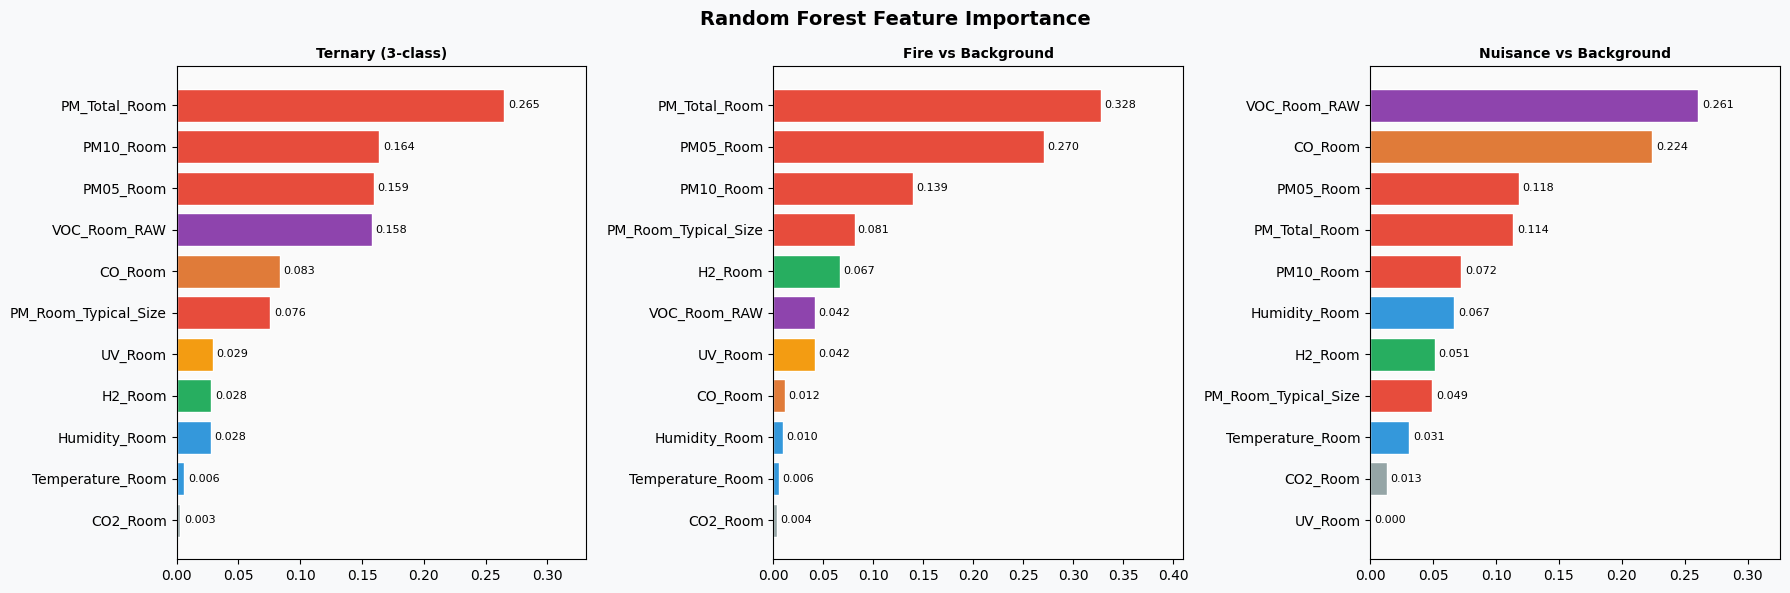

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Random Forest Feature Importance', fontsize=14, fontweight='bold')

sensor_color_map = {
    'PM_Total_Room':'#E74C3C','PM10_Room':'#E74C3C',
    'PM05_Room':'#E74C3C','PM_Room_Typical_Size':'#E74C3C',
    'VOC_Room_RAW':'#8E44AD','CO_Room':'#E07B39',
    'UV_Room':'#F39C12','H2_Room':'#27AE60',
    'Humidity_Room':'#3498DB','Temperature_Room':'#3498DB',
    'CO2_Room':'#95A5A6',
}

for ax, task in zip(axes, fi_results):
    fi_sorted = fi_results[task].sort_values(ascending=True)
    colors    = [sensor_color_map.get(s, '#888') for s in fi_sorted.index]
    ax.barh(fi_sorted.index, fi_sorted.values, color=colors, edgecolor='white')
    ax.set_title(task, fontweight='bold', fontsize=10)
    for i, val in enumerate(fi_sorted.values):
        ax.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=8)
    ax.set_xlim(0, fi_sorted.max() * 1.25)

plt.tight_layout()
plt.show()

## 14. Sensor Purchase Priority (Hardware Mapping)

In [21]:
# ── Mapping: Dataset column → physical sensor → user has? ──
hw_map = pd.DataFrame([
    {'Column':        'Temperature_Room',
     'Physical':      'DHT22 (temperature)',
     'Have':          'YES ✓',
     'Buy?':          '—',
     'Est. cost':     '$0',
     'Priority':      '—',
     'RF importance': '0.3%'},
    {'Column':        'Humidity_Room',
     'Physical':      'DHT22 (humidity)',
     'Have':          'YES ✓',
     'Buy?':          '—',
     'Est. cost':     '$0',
     'Priority':      '—',
     'RF importance': '2.8%'},
    {'Column':        'H2_Room (proxy)',
     'Physical':      'MQ2 (H2 / smoke / LPG)',
     'Have':          'YES ✓ (partial)',
     'Buy?':          '—',
     'Est. cost':     '$0',
     'Priority':      '—',
     'RF importance': '2.7%'},
    {'Column':        'PM05_Room, PM10_Room, PM_Total_Room, PM_Room_Typical_Size',
     'Physical':      'PMS5003 / SPS30 (particulate matter)',
     'Have':          'NO',
     'Buy?':          'YES — Mua ngay',
     'Est. cost':     '$15–25',
     'Priority':      '#1',
     'RF importance': '~64% (Fire)'},
    {'Column':        'VOC_Room_RAW',
     'Physical':      'SGP30 / ENS160 (VOC/TVOC)',
     'Have':          'NO',
     'Buy?':          'YES — Mua ngay',
     'Est. cost':     '$5–15',
     'Priority':      '#2',
     'RF importance': '48% (Nuisance), 15% (all)'},
    {'Column':        'CO_Room',
     'Physical':      'MQ7 / MQ9 (CO sensor)',
     'Have':          'NO (MQ2 ≠ CO)',
     'Buy?':          'Nên mua',
     'Est. cost':     '$3–8',
     'Priority':      '#3',
     'RF importance': '30% (Nuisance), 8% (all)'},
    {'Column':        'UV_Room',
     'Physical':      'GUVA-S12SD (UV)',
     'Have':          'NO',
     'Buy?':          'Tuỳ chọn (Candles only)',
     'Est. cost':     '$2–5',
     'Priority':      '#4',
     'RF importance': '3% (all), 0% (Nuisance)'},
    {'Column':        'CO2_Room',
     'Physical':      'MH-Z19B / SCD30 (CO2)',
     'Have':          'NO',
     'Buy?':          'Không cần',
     'Est. cost':     '$20–30',
     'Priority':      '#5 (skip)',
     'RF importance': '0.3% — lowest'},
]).set_index('Column')

display(hw_map.style.apply(
    lambda col: [
        'background-color: #d4f1d4' if v == 'YES ✓' else
        'background-color: #FCEBEB' if v == 'NO' else
        'background-color: #FFF3CD' if 'partial' in str(v) else ''
        for v in col
    ],
    subset=['Have']
))

print('\nTổng chi phí tối thiểu để cover đủ dataset (trừ CO2):')
print('  PMS5003 (~$20) + SGP30 (~$10) + MQ7 (~$5) ≈ $35')

,Physical,Have,Buy?,Est. cost,Priority,RF importance
Column,,,,,,
Temperature_Room,DHT22 (temperature),YES ✓,—,$0,—,0.3%
Humidity_Room,DHT22 (humidity),YES ✓,—,$0,—,2.8%
H2_Room (proxy),MQ2 (H2 / smoke / LPG),YES ✓ (partial),—,$0,—,2.7%
"PM05_Room, PM10_Room, PM_Total_Room, PM_Room_Typical_Size",PMS5003 / SPS30 (particulate matter),NO,YES — Mua ngay,$15–25,#1,~64% (Fire)
VOC_Room_RAW,SGP30 / ENS160 (VOC/TVOC),NO,YES — Mua ngay,$5–15,#2,"48% (Nuisance), 15% (all)"
CO_Room,MQ7 / MQ9 (CO sensor),NO (MQ2 ≠ CO),Nên mua,$3–8,#3,"30% (Nuisance), 8% (all)"
UV_Room,GUVA-S12SD (UV),NO,Tuỳ chọn (Candles only),$2–5,#4,"3% (all), 0% (Nuisance)"
CO2_Room,MH-Z19B / SCD30 (CO2),NO,Không cần,$20–30,#5 (skip),0.3% — lowest



Tổng chi phí tối thiểu để cover đủ dataset (trừ CO2):
  PMS5003 (~$20) + SGP30 (~$10) + MQ7 (~$5) ≈ $35


## 15. Final: Recommended Feature Set for Modeling

In [22]:
# ── Columns to keep for ML (drop redundant PM & low-importance CO2) ──
FINAL_FEATURES = [
    'CO_Room',               # CO sensor (MQ7)    — critical for nuisance
    'H2_Room',               # MQ2 proxy          — fire/cable
    'Humidity_Room',         # DHT22              — context
    'PM05_Room',             # PMS5003            — fire (fine particles)
    'PM10_Room',             # PMS5003            — fire (coarse particles)
    'PM_Total_Room',         # PMS5003            — fire (total)
    'PM_Room_Typical_Size',  # PMS5003 derived    — particle size fingerprint
    'Temperature_Room',      # DHT22              — context
    'UV_Room',               # GUVA-S12SD         — candles / open flame
    'VOC_Room_RAW',          # SGP30              — nuisance (ethanol, deodorant)
]

DROPPED = [
    'PM25_Room',   # corr=1.00 with PM40
    'PM40_Room',   # corr=1.00 with PM25
    'PM100_Room',  # corr=0.98 with PM10
    'CO2_Room',    # importance < 0.5%
]

print(f'Final feature set ({len(FINAL_FEATURES)} columns):')
for f in FINAL_FEATURES:
    print(f'  {f}')

print(f'\nDropped ({len(DROPPED)} columns):')
for d in DROPPED:
    print(f'  {d}')

# Quick sanity check
df_model = df[FINAL_FEATURES + ['ternary_label', 'scenario_label',
                                  'Sensor_ID', 'Date']].copy()
print(f'\nModeling DataFrame shape: {df_model.shape}')
display(df_model[FINAL_FEATURES].describe().round(3))

Final feature set (10 columns):
  CO_Room
  H2_Room
  Humidity_Room
  PM05_Room
  PM10_Room
  PM_Total_Room
  PM_Room_Typical_Size
  Temperature_Room
  UV_Room
  VOC_Room_RAW

Dropped (4 columns):
  PM25_Room
  PM40_Room
  PM100_Room
  CO2_Room

Modeling DataFrame shape: (305304, 14)


,CO_Room,H2_Room,Humidity_Room,PM05_Room,PM10_Room,PM_Total_Room,PM_Room_Typical_Size,Temperature_Room,UV_Room,VOC_Room_RAW
count,305304.000,305304.000,305304.000,305304.000,305304.000,305304.000,305304.000,305304.000,305304.000,305304.000
mean,0.286,0.231,44.000,994.458,193.876,1226.666,0.437,25.358,1.978,1.888
std,0.907,0.647,3.202,4303.129,984.409,5451.818,0.081,0.518,21.378,2.712
min,-1.300,-2.250,35.080,0.000,0.000,0.000,0.340,23.700,0.000,-1.600
25%,-0.140,0.020,42.040,4.000,0.000,5.000,0.400,25.000,0.000,0.800
50%,0.130,0.120,43.600,7.000,1.000,9.000,0.420,25.300,0.000,1.400
75%,0.420,0.230,45.130,14.000,2.000,16.000,0.440,25.800,0.000,1.900
max,32.220,16.360,55.970,44471.000,48301.000,93048.000,1.570,28.100,406.000,75.300


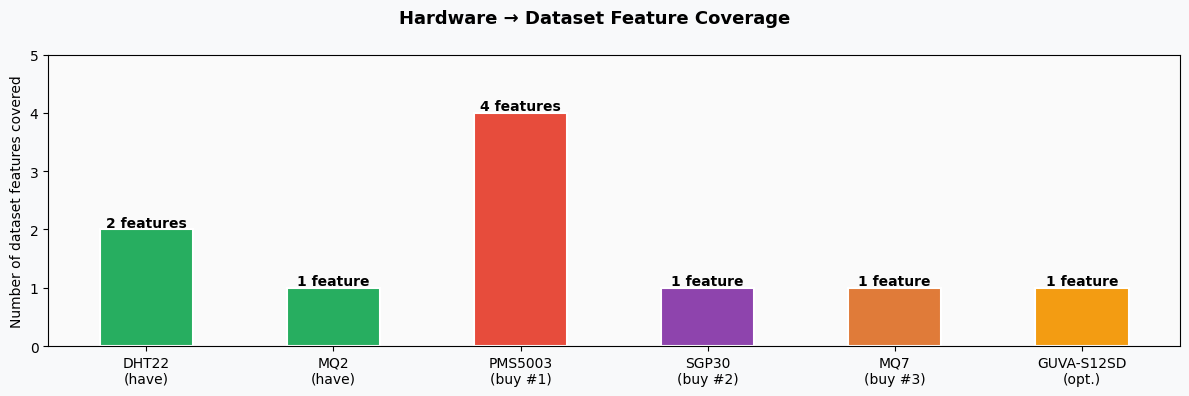


✅ Final sensor shopping list:
  #1 PMS5003 or SPS30  — particulate matter  (~$15–25) — CRITICAL for fire
  #2 SGP30 or ENS160   — VOC/TVOC            (~$5–15)  — CRITICAL for nuisance
  #3 MQ7 or MQ9        — CO                  (~$3–8)   — important for nuisance
  #4 GUVA-S12SD        — UV                  (~$2–5)   — optional (candles only)
  #5 MH-Z19B           — CO2                 (~$20–30) — NOT recommended (0.3% importance)

  Total min. budget: ~$23–48 (without CO2)


In [23]:
# ── Summary bar: what each hardware sensor covers ──
coverage = {
    'DHT22\n(have)':       {'features': 2, 'color': '#27AE60'},
    'MQ2\n(have)':         {'features': 1, 'color': '#27AE60'},
    'PMS5003\n(buy #1)':   {'features': 4, 'color': '#E74C3C'},
    'SGP30\n(buy #2)':     {'features': 1, 'color': '#8E44AD'},
    'MQ7\n(buy #3)':       {'features': 1, 'color': '#E07B39'},
    'GUVA-S12SD\n(opt.)':  {'features': 1, 'color': '#F39C12'},
}

fig, ax = plt.subplots(figsize=(12, 4))
fig.suptitle('Hardware → Dataset Feature Coverage', fontsize=13, fontweight='bold')
names  = list(coverage.keys())
vals   = [coverage[k]['features'] for k in names]
colors = [coverage[k]['color'] for k in names]
bars = ax.bar(names, vals, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val} feature{"s" if val > 1 else ""}',
            ha='center', fontweight='bold', fontsize=10)
ax.set_ylabel('Number of dataset features covered')
ax.set_ylim(0, 5)
ax.set_facecolor('#FAFAFA')
ax.axhline(0, color='#2C3E50', linewidth=0.5)
plt.tight_layout()
plt.show()

print('\n✅ Final sensor shopping list:')
print('  #1 PMS5003 or SPS30  — particulate matter  (~$15–25) — CRITICAL for fire')
print('  #2 SGP30 or ENS160   — VOC/TVOC            (~$5–15)  — CRITICAL for nuisance')
print('  #3 MQ7 or MQ9        — CO                  (~$3–8)   — important for nuisance')
print('  #4 GUVA-S12SD        — UV                  (~$2–5)   — optional (candles only)')
print('  #5 MH-Z19B           — CO2                 (~$20–30) — NOT recommended (0.3% importance)')
print('\n  Total min. budget: ~$23–48 (without CO2)')